# Simulation Analysis

This notebook analyzes the outputs of the Monte Carlo tournament simulation used in the **World Cup 2026 Forecast** project.

The objective is to evaluate the tournament-level behavior of the forecasting engine, inspect team advancement probabilities, understand champion distributions, and assess simulation stability.

This notebook focuses on:

- forecast output inspection
- team progression probabilities
- champion distribution analysis
- upset and uncertainty patterns
- simulation stability and convergence
- interpretation of tournament-level results

> Results based on 10,000 Monte Carlo simulations using the v2 tournament format.

## Project paths setup

Resolve project root and load simulation artifacts generated by the tournament simulation engine.

In [2]:
from pathlib import Path

# Detect project root
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Simulation outputs directory
SIM_OUTPUT = PROJECT_ROOT / "data" / "outputs" / "simulation"

team_probs = SIM_OUTPUT / "team_probabilities.csv"
champion_dist = SIM_OUTPUT / "champion_distribution.csv"
summary_metadata_path = SIM_OUTPUT / "summary_metadata.json"
match_logs_path = SIM_OUTPUT / "match_logs.parquet"

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

team_probabilities = pd.read_csv(team_probs)
champion_distribution = pd.read_csv(champion_dist)

summary_metadata = None
if summary_metadata_path.exists():
    with open(summary_metadata_path) as f:
        summary_metadata = json.load(f)

match_logs_df = None
if match_logs_path.exists():
    match_logs_df = pd.read_parquet(match_logs_path)

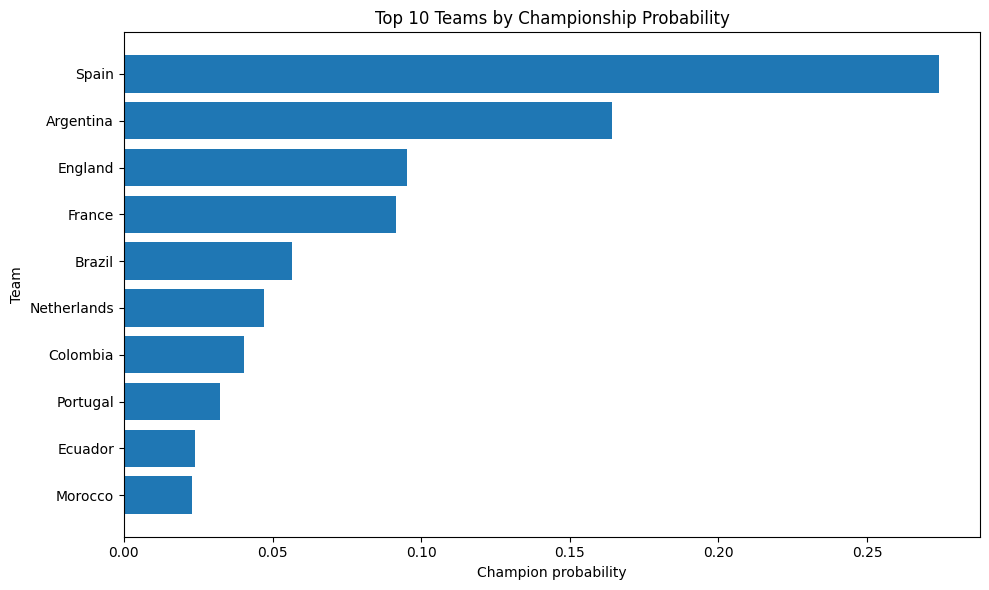

In [4]:
top_10_champion = champion_distribution.sort_values(
    "champion_prob",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))
plt.barh(top_10_champion["team"], top_10_champion["champion_prob"])

plt.xlabel("Champion probability")
plt.ylabel("Team")
plt.title("Top 10 Teams by Championship Probability")

plt.gca().invert_yaxis()
plt.tight_layout()

output_dir = PROJECT_ROOT / "docs" / "images"
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / "champion_probabilities.png", dpi=300)

plt.show()

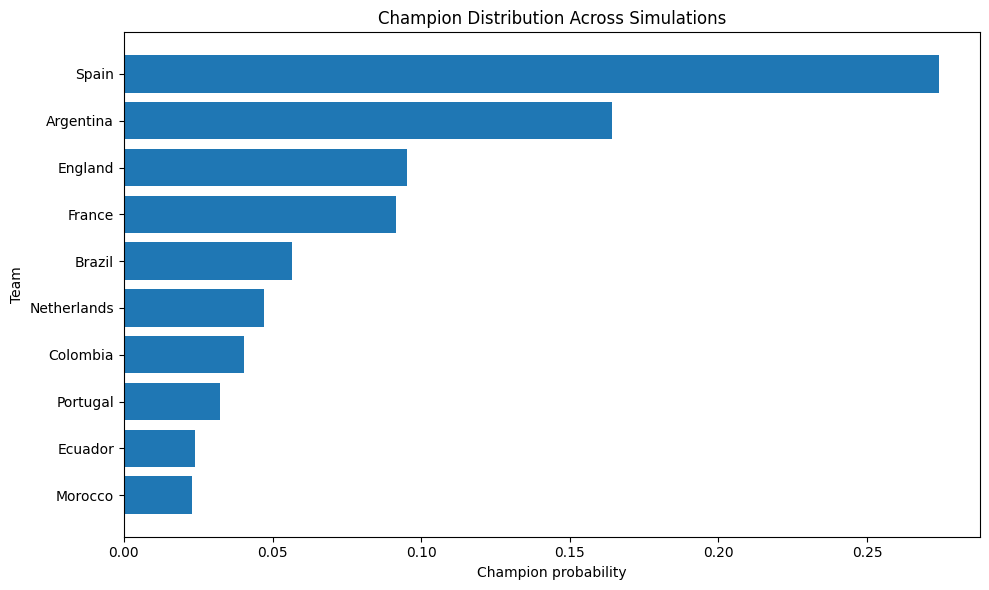

In [5]:
top_10_distribution = (
    champion_distribution
    .sort_values("champion_prob", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.barh(top_10_distribution["team"], top_10_distribution["champion_prob"])

plt.xlabel("Champion probability")
plt.ylabel("Team")
plt.title("Champion Distribution Across Simulations")

plt.gca().invert_yaxis()
plt.tight_layout()

output_dir = PROJECT_ROOT / "docs" / "images"
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / "champion_distribution.png", dpi=300)

plt.show()

## Project paths

This notebook expects simulation outputs exported by the reporting layer, including:

- `team_probabilities.csv`
- `champion_distribution.csv`
- `match_logs.parquet`
- `summary_metadata.json`

In [6]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
SIM_OUTPUT_DIR = PROJECT_ROOT / "data" / "outputs" / "simulation"

TEAM_PROB_PATH = SIM_OUTPUT_DIR / "team_probabilities.csv"
CHAMPION_DIST_PATH = SIM_OUTPUT_DIR / "champion_distribution.csv"
MATCH_LOGS_PATH = SIM_OUTPUT_DIR / "match_logs.parquet"
SUMMARY_METADATA_PATH = SIM_OUTPUT_DIR / "summary_metadata.json"

PROJECT_ROOT, SIM_OUTPUT_DIR

(WindowsPath('C:/Users/manue/Projects/world-cup-2026-forecast'),
 WindowsPath('C:/Users/manue/Projects/world-cup-2026-forecast/data/outputs/simulation'))

In [7]:
required_paths = [
    TEAM_PROB_PATH,
    CHAMPION_DIST_PATH,
    MATCH_LOGS_PATH,
    SUMMARY_METADATA_PATH,
]

missing_paths = [str(path) for path in required_paths if not path.exists()]

if missing_paths:
    raise FileNotFoundError(
        "Missing simulation artifacts:\n- " + "\n- ".join(missing_paths)
    )

print("All required simulation artifacts found.")

All required simulation artifacts found.


## Load simulation artifacts

In [8]:
team_prob_df = pd.read_csv(TEAM_PROB_PATH)
champion_dist_df = pd.read_csv(CHAMPION_DIST_PATH)
match_logs_df = pd.read_parquet(MATCH_LOGS_PATH)

with open(SUMMARY_METADATA_PATH, "r", encoding="utf-8") as f:
    summary_metadata = json.load(f)

print("team_prob_df:", team_prob_df.shape)
print("champion_dist_df:", champion_dist_df.shape)
print("match_logs_df:", match_logs_df.shape)
summary_metadata

team_prob_df: (48, 10)
champion_dist_df: (37, 3)
match_logs_df: (1030000, 12)


{'tournament_name': 'FIFA World Cup 2026 - Simplified',
 'tournament_id': 'world_cup_2026_simplified',
 'model_name': 'logistic_regression',
 'neutral_venue': 1,
 'knockout_draw_resolution': 'elo_weighted',
 'num_groups': 12,
 'group_size': 4,
 'teams_advancing_per_group': 2,
 'best_third_qualifiers': 8,
 'initial_knockout_round': 'round_of_32',
 'num_simulations': 10000,
 'num_teams': 48}

## Metadata summary

In [9]:
metadata_df = pd.DataFrame([summary_metadata])
metadata_df

,tournament_name,tournament_id,model_name,neutral_venue,knockout_draw_resolution,num_groups,group_size,teams_advancing_per_group,best_third_qualifiers,initial_knockout_round,num_simulations,num_teams
0,FIFA World Cup 2026 - Simplified,world_cup_2026_simplified,logistic_regression,1,elo_weighted,12,4,2,8,round_of_32,10000,48


## Team probability table overview

In [10]:
team_prob_df.head(10)

,team,group_stage_exit_prob,round_of_32_prob,round_of_16_prob,quarterfinal_prob,semifinal_prob,final_prob,champion_prob,advance_from_group_prob,non_champion_prob
0,Spain,0.0051,0.9949,0.8647,0.7167,0.5452,0.4255,0.2743,0.9949,0.7257
1,Argentina,0.0212,0.9788,0.8239,0.5678,0.3842,0.2591,0.1643,0.9788,0.8357
2,England,0.0198,0.9802,0.7473,0.4791,0.2747,0.1703,0.0952,0.9802,0.9048
3,France,0.0476,0.9524,0.7651,0.4278,0.2605,0.1579,0.0914,0.9524,0.9086
4,Brazil,0.0239,0.9761,0.6708,0.4688,0.3066,0.1306,0.0567,0.9761,0.9433
5,Netherlands,0.0494,0.9506,0.6641,0.4105,0.1868,0.1052,0.0471,0.9506,0.9529
6,Colombia,0.0121,0.9879,0.5838,0.3132,0.1662,0.0805,0.0404,0.9879,0.9596
7,Portugal,0.0099,0.9901,0.5806,0.3128,0.1516,0.0705,0.0324,0.9901,0.9676
8,Ecuador,0.0768,0.9232,0.5898,0.3171,0.1383,0.0630,0.0238,0.9232,0.9762
9,Morocco,0.0412,0.9588,0.5241,0.2967,0.1493,0.0569,0.0228,0.9588,0.9772


In [11]:
team_prob_df.columns.tolist()

['team',
 'group_stage_exit_prob',
 'round_of_32_prob',
 'round_of_16_prob',
 'quarterfinal_prob',
 'semifinal_prob',
 'final_prob',
 'champion_prob',
 'advance_from_group_prob',
 'non_champion_prob']

## Sort teams by championship probability

In [12]:
team_prob_sorted = team_prob_df.sort_values("champion_prob", ascending=False).reset_index(drop=True)
team_prob_sorted.head(20)

,team,group_stage_exit_prob,round_of_32_prob,round_of_16_prob,quarterfinal_prob,semifinal_prob,final_prob,champion_prob,advance_from_group_prob,non_champion_prob
0,Spain,0.0051,0.9949,0.8647,0.7167,0.5452,0.4255,0.2743,0.9949,0.7257
1,Argentina,0.0212,0.9788,0.8239,0.5678,0.3842,0.2591,0.1643,0.9788,0.8357
2,England,0.0198,0.9802,0.7473,0.4791,0.2747,0.1703,0.0952,0.9802,0.9048
3,France,0.0476,0.9524,0.7651,0.4278,0.2605,0.1579,0.0914,0.9524,0.9086
4,Brazil,0.0239,0.9761,0.6708,0.4688,0.3066,0.1306,0.0567,0.9761,0.9433
5,Netherlands,0.0494,0.9506,0.6641,0.4105,0.1868,0.1052,0.0471,0.9506,0.9529
6,Colombia,0.0121,0.9879,0.5838,0.3132,0.1662,0.0805,0.0404,0.9879,0.9596
7,Portugal,0.0099,0.9901,0.5806,0.3128,0.1516,0.0705,0.0324,0.9901,0.9676
8,Ecuador,0.0768,0.9232,0.5898,0.3171,0.1383,0.0630,0.0238,0.9232,0.9762
9,Morocco,0.0412,0.9588,0.5241,0.2967,0.1493,0.0569,0.0228,0.9588,0.9772


## Top teams by championship probability

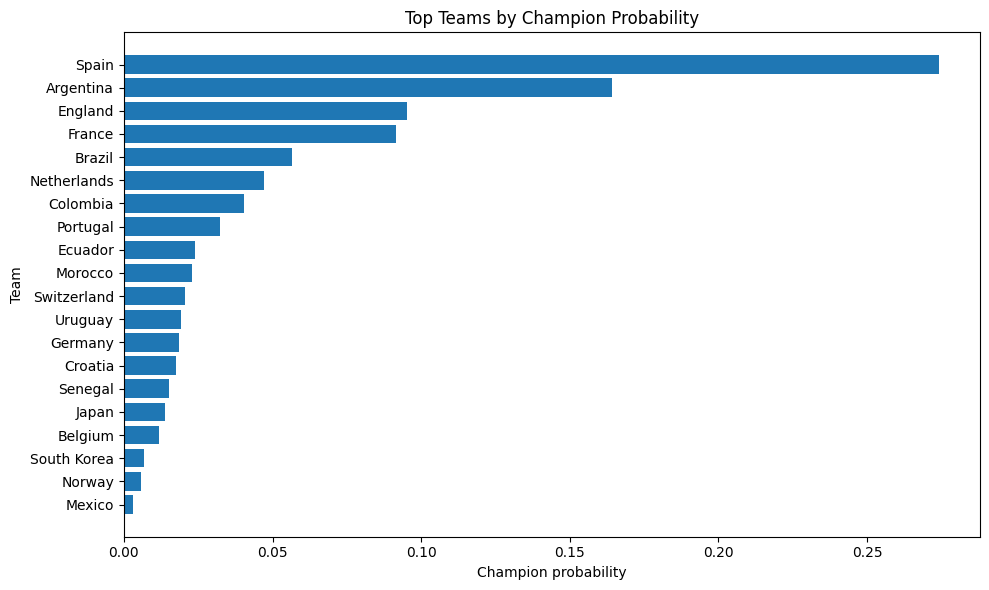

In [13]:
top_n = min(20, len(team_prob_sorted))
top_champ = team_prob_sorted.head(top_n).copy()

plt.figure(figsize=(10, 6))
plt.barh(top_champ["team"][::-1], top_champ["champion_prob"][::-1])
plt.xlabel("Champion probability")
plt.ylabel("Team")
plt.title("Top Teams by Champion Probability")
plt.tight_layout()
plt.show()

## Progression probability columns

In [14]:
probability_cols = [col for col in team_prob_df.columns if col.endswith("_prob")]
probability_cols

['group_stage_exit_prob',
 'round_of_32_prob',
 'round_of_16_prob',
 'quarterfinal_prob',
 'semifinal_prob',
 'final_prob',
 'champion_prob',
 'advance_from_group_prob',
 'non_champion_prob']

## Team progression table

In [15]:
team_prob_sorted.head(15)

,team,group_stage_exit_prob,round_of_32_prob,round_of_16_prob,quarterfinal_prob,semifinal_prob,final_prob,champion_prob,advance_from_group_prob,non_champion_prob
0,Spain,0.0051,0.9949,0.8647,0.7167,0.5452,0.4255,0.2743,0.9949,0.7257
1,Argentina,0.0212,0.9788,0.8239,0.5678,0.3842,0.2591,0.1643,0.9788,0.8357
2,England,0.0198,0.9802,0.7473,0.4791,0.2747,0.1703,0.0952,0.9802,0.9048
3,France,0.0476,0.9524,0.7651,0.4278,0.2605,0.1579,0.0914,0.9524,0.9086
4,Brazil,0.0239,0.9761,0.6708,0.4688,0.3066,0.1306,0.0567,0.9761,0.9433
5,Netherlands,0.0494,0.9506,0.6641,0.4105,0.1868,0.1052,0.0471,0.9506,0.9529
6,Colombia,0.0121,0.9879,0.5838,0.3132,0.1662,0.0805,0.0404,0.9879,0.9596
7,Portugal,0.0099,0.9901,0.5806,0.3128,0.1516,0.0705,0.0324,0.9901,0.9676
8,Ecuador,0.0768,0.9232,0.5898,0.3171,0.1383,0.0630,0.0238,0.9232,0.9762
9,Morocco,0.0412,0.9588,0.5241,0.2967,0.1493,0.0569,0.0228,0.9588,0.9772


## Advancement ladder visualization for top contenders

In [16]:
stage_order = [
    col for col in [
        "advance_from_group_prob",
        "round_of_32_prob",
        "round_of_16_prob",
        "quarterfinal_prob",
        "semifinal_prob",
        "final_prob",
        "champion_prob",
    ]
    if col in team_prob_sorted.columns
]

top_k = min(8, len(team_prob_sorted))
ladder_df = (
    team_prob_sorted.loc[:top_k-1, ["team"] + stage_order]
    .set_index("team")
    .T
)

ladder_df

team,Spain,Argentina,England,France,Brazil,Netherlands,Colombia,Portugal
advance_from_group_prob,0.9949,0.9788,0.9802,0.9524,0.9761,0.9506,0.9879,0.9901
round_of_32_prob,0.9949,0.9788,0.9802,0.9524,0.9761,0.9506,0.9879,0.9901
round_of_16_prob,0.8647,0.8239,0.7473,0.7651,0.6708,0.6641,0.5838,0.5806
quarterfinal_prob,0.7167,0.5678,0.4791,0.4278,0.4688,0.4105,0.3132,0.3128
semifinal_prob,0.5452,0.3842,0.2747,0.2605,0.3066,0.1868,0.1662,0.1516
final_prob,0.4255,0.2591,0.1703,0.1579,0.1306,0.1052,0.0805,0.0705
champion_prob,0.2743,0.1643,0.0952,0.0914,0.0567,0.0471,0.0404,0.0324


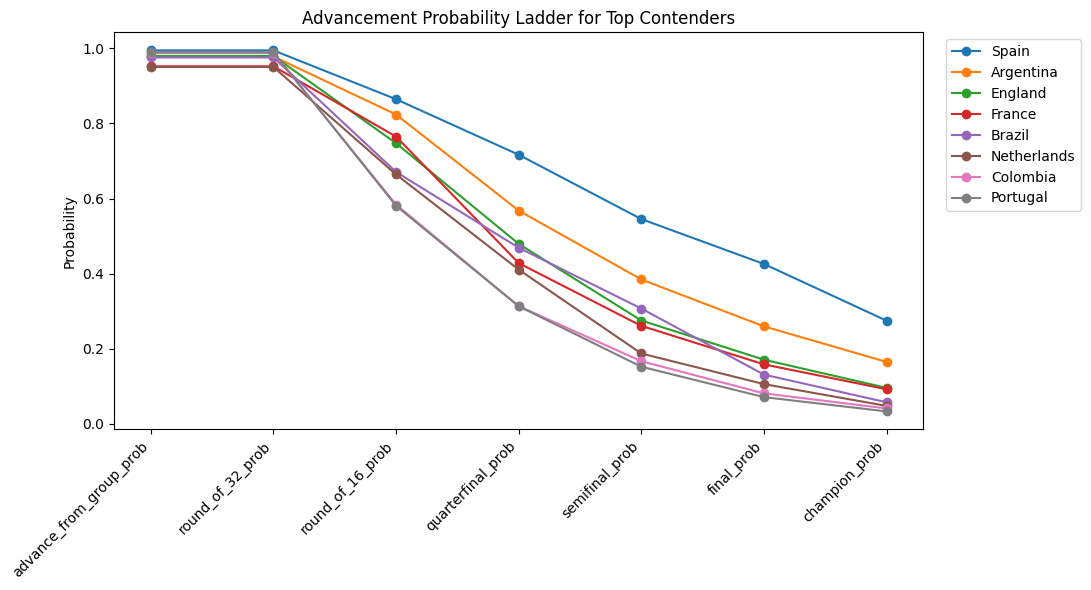

In [17]:
if len(stage_order) > 0:
    plt.figure(figsize=(11, 6))
    for team in ladder_df.columns:
        plt.plot(ladder_df.index, ladder_df[team], marker="o", label=team)

    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Probability")
    plt.title("Advancement Probability Ladder for Top Contenders")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("No stage probability columns found.")

## Champion distribution

In [18]:
champion_dist_sorted = champion_dist_df.sort_values("champion_prob", ascending=False).reset_index(drop=True)
champion_dist_sorted.head(20)

,team,titles,champion_prob
0,Spain,2743,0.2743
1,Argentina,1643,0.1643
2,England,952,0.0952
3,France,914,0.0914
4,Brazil,567,0.0567
5,Netherlands,471,0.0471
6,Colombia,404,0.0404
7,Portugal,324,0.0324
8,Ecuador,238,0.0238
9,Morocco,228,0.0228


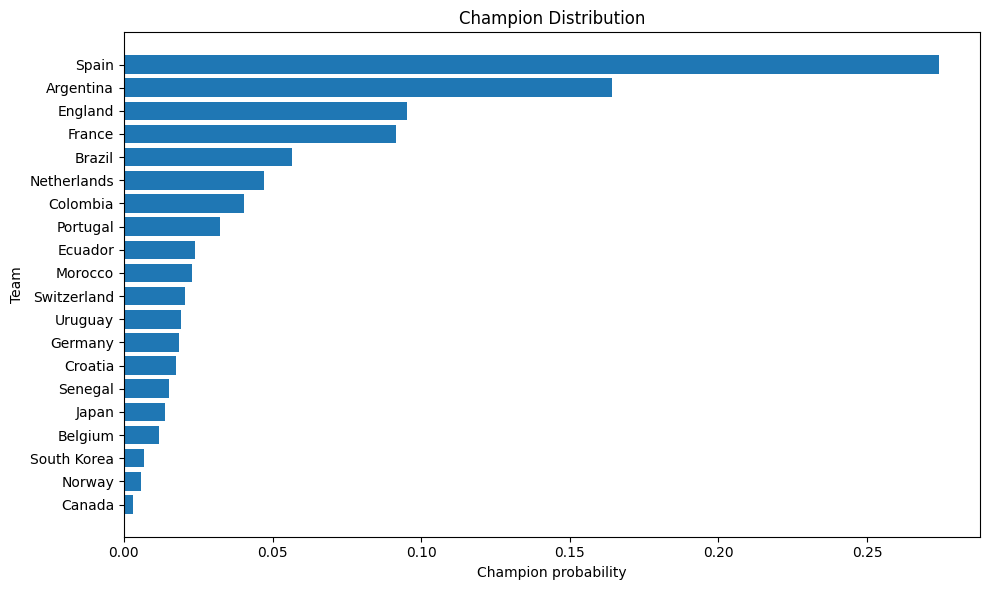

In [19]:
top_n = min(20, len(champion_dist_sorted))
top_champion_dist = champion_dist_sorted.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_champion_dist["team"][::-1], top_champion_dist["champion_prob"][::-1])
plt.xlabel("Champion probability")
plt.ylabel("Team")
plt.title("Champion Distribution")
plt.tight_layout()
plt.show()

## Forecast concentration

In [20]:
top_5_mass = champion_dist_sorted["champion_prob"].head(5).sum()
top_10_mass = champion_dist_sorted["champion_prob"].head(10).sum()
entropy = -(champion_dist_sorted["champion_prob"] * np.log(np.clip(champion_dist_sorted["champion_prob"], 1e-12, 1))).sum()

pd.DataFrame([{
    "top_5_champion_probability_mass": top_5_mass,
    "top_10_champion_probability_mass": top_10_mass,
    "champion_distribution_entropy": entropy,
}]).round(4)

,top_5_champion_probability_mass,top_10_champion_probability_mass,champion_distribution_entropy
0,0.6819,0.8484,2.4962


## Match log overview

In [21]:
match_logs_df.head()

,simulation_id,stage,team_a,team_b,outcome,winner,decided_by,team_a_win_prob,draw_prob,team_a_loss_prob,team_a_goals,team_b_goals
0,0,group_A,Mexico,South Africa,win,Mexico,regular_time,0.561102,0.265659,0.173239,None,None
1,0,group_A,Mexico,South Korea,loss,South Korea,regular_time,0.339605,0.309803,0.350592,None,None
2,0,group_A,Mexico,Czech Republic,draw,None,regular_time,0.472375,0.289609,0.238016,None,None
3,0,group_A,South Africa,South Korea,loss,South Korea,regular_time,0.185457,0.281819,0.532724,None,None
4,0,group_A,South Africa,Czech Republic,win,South Africa,regular_time,0.288453,0.309074,0.402473,None,None


In [22]:
match_logs_df.columns.tolist()

['simulation_id',
 'stage',
 'team_a',
 'team_b',
 'outcome',
 'winner',
 'decided_by',
 'team_a_win_prob',
 'draw_prob',
 'team_a_loss_prob',
 'team_a_goals',
 'team_b_goals']

## Stage distribution in the simulation logs

In [23]:
if "stage" in match_logs_df.columns:
    stage_counts = match_logs_df["stage"].value_counts().sort_index()
    stage_counts.to_frame("num_matches")
else:
    print("No 'stage' column found in match logs.")

## Outcome distribution in simulated matches

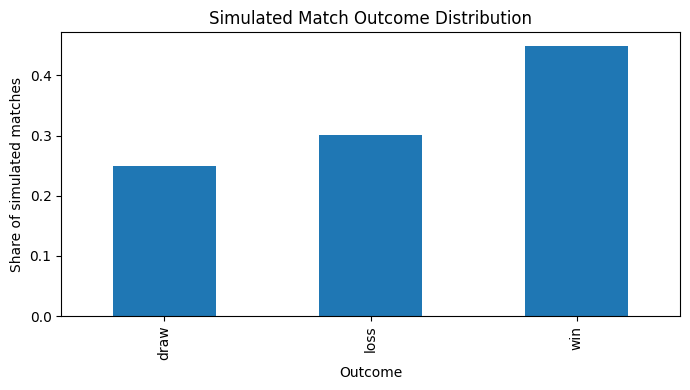

In [24]:
if "outcome" in match_logs_df.columns:
    outcome_counts = match_logs_df["outcome"].value_counts(normalize=True).sort_index()
    outcome_counts.plot(kind="bar", figsize=(7, 4))
    plt.title("Simulated Match Outcome Distribution")
    plt.xlabel("Outcome")
    plt.ylabel("Share of simulated matches")
    plt.tight_layout()
    plt.show()
else:
    print("No 'outcome' column found in match logs.")

## Upset analysis

We define a simple upset proxy using pre-match win probabilities:

- if Team A wins with a low Team A win probability
- if Team B wins with a low Team B win probability inferred from the logged probabilities

This is not a perfect upset definition, but it provides a useful high-level signal.

In [25]:
upset_df = match_logs_df.copy()

required_upset_cols = {"team_a", "team_b", "team_a_win_prob", "team_b_win_prob", "winner"}
if required_upset_cols.issubset(upset_df.columns):
    upset_df["winner_pre_match_prob"] = np.where(
        upset_df["winner"] == upset_df["team_a"],
        upset_df["team_a_win_prob"],
        np.where(
            upset_df["winner"] == upset_df["team_b"],
            upset_df["team_b_win_prob"],
            np.nan,
        ),
    )

    upset_df["is_upset_20"] = (upset_df["winner_pre_match_prob"] < 0.20).astype(int)
    upset_df["is_upset_30"] = (upset_df["winner_pre_match_prob"] < 0.30).astype(int)

    pd.DataFrame([{
        "upset_rate_below_20pct": upset_df["is_upset_20"].mean(),
        "upset_rate_below_30pct": upset_df["is_upset_30"].mean(),
    }]).round(4)
else:
    print("Required probability columns for upset analysis are not available.")

Required probability columns for upset analysis are not available.


In [26]:
if "winner_pre_match_prob" in upset_df.columns:
    upset_df["winner_pre_match_prob"].hist(bins=30, figsize=(8, 4))
    plt.title("Distribution of Winner Pre-Match Probability")
    plt.xlabel("Winner pre-match probability")
    plt.ylabel("Number of simulated matches")
    plt.tight_layout()
    plt.show()

## Most surprising simulated matches

In [27]:
if "winner_pre_match_prob" in upset_df.columns:
    surprising_matches = (
        upset_df.sort_values("winner_pre_match_prob", ascending=True)
        .head(20)
    )
    surprising_matches
else:
    print("Upset proxy not available.")

Upset proxy not available.


## Team-level uncertainty profile

In [28]:
if set(["final_prob", "champion_prob"]).issubset(team_prob_sorted.columns):
    uncertainty_profile = team_prob_sorted[["team", "final_prob", "champion_prob"]].copy()
    uncertainty_profile["conversion_final_to_title"] = np.where(
        uncertainty_profile["final_prob"] > 0,
        uncertainty_profile["champion_prob"] / uncertainty_profile["final_prob"],
        np.nan,
    )
    uncertainty_profile.sort_values("final_prob", ascending=False).head(20)
else:
    print("final_prob and champion_prob are required for this section.")

## Simulation stability and convergence

To study stability, we recompute champion probability estimates using increasing prefixes of simulation runs.

This requires a `simulation_id` column in the match logs and one final-stage match per tournament run.

In [29]:
if {"simulation_id", "stage", "winner"}.issubset(match_logs_df.columns):
    final_stage_candidates = [stage for stage in match_logs_df["stage"].dropna().unique() if "final" in str(stage).lower()]
    final_stage_candidates
else:
    print("Required columns for convergence analysis are not available.")

In [30]:
convergence_df = None

if {"simulation_id", "stage", "winner"}.issubset(match_logs_df.columns):
    final_stage_candidates = [stage for stage in match_logs_df["stage"].dropna().unique() if "final" in str(stage).lower()]

    if len(final_stage_candidates) > 0:
        final_stage_name = sorted(final_stage_candidates, key=lambda x: str(x))[-1]

        final_matches = (
            match_logs_df[match_logs_df["stage"] == final_stage_name]
            .sort_values("simulation_id")
            .copy()
        )

        champions_by_run = final_matches[["simulation_id", "winner"]].dropna().rename(columns={"winner": "champion"})

        checkpoints = []
        total_runs = len(champions_by_run)

        if total_runs > 0:
            for n in [100, 500, 1000, 5000, 10000, total_runs]:
                if n <= total_runs:
                    tmp = (
                        champions_by_run.head(n)["champion"]
                        .value_counts(normalize=True)
                        .rename_axis("team")
                        .reset_index(name="champion_prob_prefix")
                    )
                    tmp["num_simulations"] = n
                    checkpoints.append(tmp)

            if checkpoints:
                convergence_df = pd.concat(checkpoints, ignore_index=True)

convergence_df.head() if convergence_df is not None else print("Convergence analysis unavailable for current logs.")

,team,champion_prob_prefix,num_simulations
0,Spain,0.29,100
1,Argentina,0.16,100
2,Brazil,0.07,100
3,Netherlands,0.07,100
4,England,0.06,100


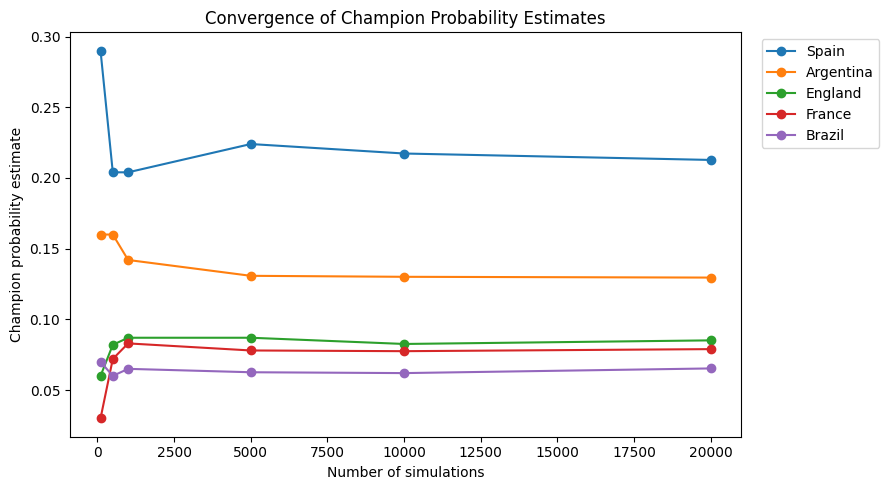

In [31]:
if convergence_df is not None:
    top_teams = champion_dist_sorted.head(min(5, len(champion_dist_sorted)))["team"].tolist()
    plot_df = convergence_df[convergence_df["team"].isin(top_teams)].copy()

    plt.figure(figsize=(9, 5))
    for team in top_teams:
        team_df = plot_df[plot_df["team"] == team].sort_values("num_simulations")
        if len(team_df) > 0:
            plt.plot(team_df["num_simulations"], team_df["champion_prob_prefix"], marker="o", label=team)

    plt.xlabel("Number of simulations")
    plt.ylabel("Champion probability estimate")
    plt.title("Convergence of Champion Probability Estimates")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("Convergence plot unavailable.")

## Simulation results overview

The Monte Carlo simulation provides a probabilistic view of the tournament landscape by repeatedly sampling match outcomes using the trained match prediction model under the updated 48-team bracket (v2 format).

Across the simulated tournaments, the forecast identifies a clear leading contender alongside a competitive group of strong teams, while still preserving meaningful uncertainty in the overall champion distribution.

---

## Tournament favorites

The simulation results indicate that **Spain emerges as the dominant title contender**, with a championship probability of approximately **27%**.

**Argentina follows as the second strongest team**, with a championship probability around **16%**, forming a clear top tier.

A second group of competitive teams includes **England, France, Brazil, and the Netherlands**, with championship probabilities generally ranging between **4% and 10%**, reflecting both their underlying strength and sensitivity to knockout dynamics.

Additional teams such as **Colombia, Portugal, and Ecuador** maintain non-negligible title chances, benefiting from favorable progression paths in some simulations.

---

## Tournament progression dynamics

The progression probabilities highlight clear structural differences between top-tier teams and the rest of the field:

* **Spain** maintains consistently high probabilities across all stages, with strong likelihoods of reaching the semifinal and final rounds.
* **Argentina** also shows robust progression, though with slightly more variance in later stages.
* Teams like **England and France** display solid advancement probabilities but experience sharper drop-offs at the semifinal and final stages, indicating greater dependence on matchup difficulty.
* Mid-tier teams often reach the **Round of 16 or quarterfinals** with reasonable probability, but their chances of advancing further decline significantly against elite opponents.

This analysis helps distinguish **true title contenders** from teams that are structurally more likely to exit in the mid-to-late knockout rounds.

---

## Forecast concentration and uncertainty

The concentration of championship probability reflects a moderately concentrated but still uncertain tournament:

* The **top 5 teams account for a majority of total championship probability**, indicating a relatively strong concentration of contenders.
* The **top 10 teams capture most of the probability mass**, though a meaningful share remains distributed across lower-probability teams.

Despite the presence of a dominant favorite, the distribution remains sufficiently spread to reflect the inherent randomness of knockout tournaments.

---

## Implications for tournament forecasting

These results illustrate the value of combining **match-level probabilistic models with Monte Carlo tournament simulation**, particularly under complex tournament structures such as the expanded 48-team World Cup format.

While the match model captures relative team strength and contextual performance signals, the tournament simulation translates those probabilities into:

* stage-level advancement likelihoods,
* championship probabilities,
* and realistic knockout dynamics.

This approach enables a more comprehensive understanding of tournament outcomes compared to match-level predictions alone.

---

## Limitations and future improvements

Several extensions could further improve the realism and predictive performance of the simulation framework:

1. **Improved match prediction models**, including gradient boosting methods such as LightGBM or XGBoost.
2. **Goal-based modeling approaches**, enabling simulation of scorelines rather than categorical outcomes.
3. **Enhanced probability calibration**, ensuring consistency between predicted and realized frequencies in simulation.
4. **Bracket realism improvements**, incorporating more accurate mappings for third-place qualifiers if required.
5. **Scenario analysis**, evaluating sensitivity to team strength updates or alternative group-stage configurations.

## Next steps

Planned follow-up work:

1. Re-run the notebook once the final 2026 qualified teams and official groups are known.
2. Compare forecast outputs across alternative match prediction models.
3. Assess whether calibration improvements at match level translate into better tournament-level probabilities.
4. Add richer visualizations for bracket progression and team-to-team comparison.
5. Extend the simulation engine toward goal-based scoreline models.